# Overlapping Distributions with KDE Ridge Plots

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_theme(style='white', rc={'axes.facecolor': (0, 0, 0, 0)})

In [ ]:
rs = np.random.RandomState(1979)
x = rs.randn(500)

# Take a string of letters, turn it into a list containing each letter, and
# append a copy of this list to the end of it 50 times:
g = np.tile(list('ABCDEFGHIJ'), 50)

# Create a DataFrame using the random numbers added to the ASCII values of
# each letter in the original list:
df = pd.DataFrame(dict(x=x, g=g))
m = df.g.map(ord)
df['x'] += m

df.head()

,x,g
0,64.038123,A
1,66.147050,B
2,66.370011,C
3,68.791019,D
4,70.583534,E


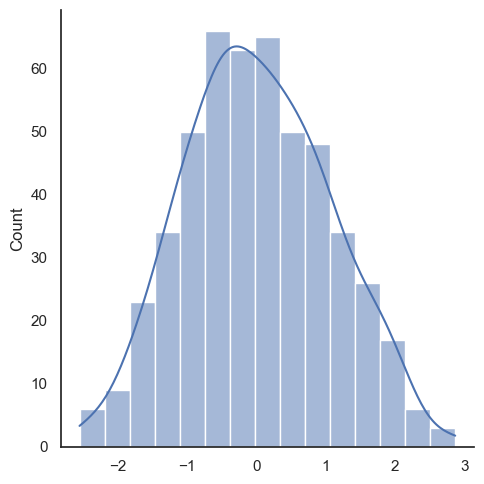

In [7]:
sns.displot(
    x=x,
    kde=True
)

In [12]:
pal = sns.cubehelix_palette(10, rot=-0.25, light=.7)
print(pal)

[[0.5632111255041908, 0.758620966612444, 0.7764634182455045], [0.49310949326943354, 0.695289848654309, 0.7369248563168074], [0.43053405133665246, 0.6285008498924174, 0.6954071975008917], [0.3781016811140187, 0.5633546614344814, 0.6530658354036274], [0.327895890323472, 0.4919215782285458, 0.6027220132499856], [0.28237964114259645, 0.41934974608112663, 0.5456963740843879], [0.2426591079772084, 0.3511228226876375, 0.4852103253459974], [0.20186205788464665, 0.27907770482747657, 0.41248899402135375], [0.1635175490164578, 0.21308372438018483, 0.33627337988703215], [0.12071162840208301, 0.14526386650440642, 0.2463679091477368]]


c:\Users\jkant\miniconda3\envs\datavis\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\jkant\miniconda3\envs\datavis\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\jkant\miniconda3\envs\datavis\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\jkant\miniconda3\envs\datavis\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args

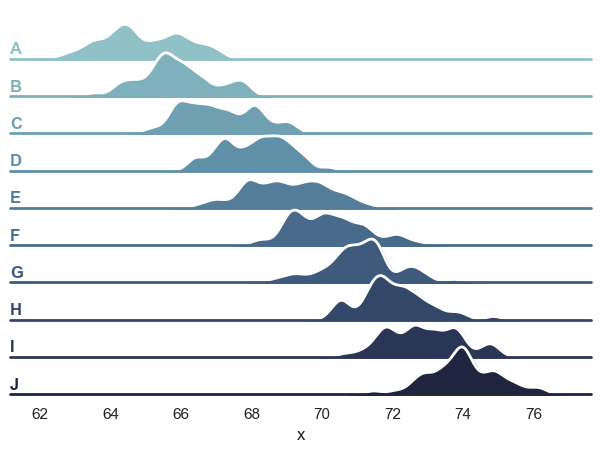

In [ ]:
g = sns.FacetGrid(
    data=df,
    row='g',
    hue='g',
    aspect=15,
    height=0.5,
    palette=pal
)

g.map(sns.kdeplot, 'x', bw_adjust=0.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, 'x', clip_on=False, color='w', lw=2, bw_adjust=0.5)

g.refline(y=0, linewidth=2, linestyle='-', color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, 0.2, label, fontweight='bold', color=color,
            ha='left', va='center', transform=ax.transAxes)
    
g.map(label, 'x')

g.figure.subplots_adjust(hspace=-0.25)

g.set_titles('')
g.set(yticks=[], ylabel='')
g.despine(bottom=True, left=True)

- [KDE Ridgeplot example](https://seaborn.pydata.org/examples/kde_ridgeplot.html)